In [22]:
%pip install -q requests pydantic python-dotenv pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [23]:
import os, re, sys, json, time, ast, operator, subprocess
from pathlib import Path
from dataclasses import dataclass, field
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, ValidationError

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"
GUARDIAN_API_KEY = os.getenv("GUARDIAN_API_KEY")
CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}",
           "HTTP-Referer": "https://postypashki.ru", "X-Title": "agents-course-seminar01"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("qa_data"), Path("/kaggle/input/datasets/artmakar04/"), Path("/kaggle/input/seminar01-data/data")]
             if (p / "compare_10.jsonl").exists()), Path("qa-data"))
TRACES, IMG = Path("traces"), Path("img")
TRACES.mkdir(exist_ok=True)
IMG.mkdir(exist_ok=True)

In [24]:
@dataclass
class Ledger:
    calls: list = field(default_factory=list)

    def add(self, tag, model, usage, seconds=0.0):
        p, c = usage.get("prompt_tokens", 0), usage.get("completion_tokens", 0)
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": p, "completion": c,
                           "cost": cost, "seconds": round(seconds, 2)})
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    def table(self):
        df = pd.DataFrame(self.calls)
        return df.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                completion=("completion", "sum"), cost=("cost", "sum"),
                                                seconds=("seconds", "sum")).round(5)

ledger = Ledger()

def post_with_retry(body, attempts=3):
    for attempt in range(attempts):
        r = requests.post(CHAT_URL, json=body, headers=HEADERS, timeout=120)
        if r.status_code == 200:
            return r.json()
        if r.status_code in (429, 500, 502, 503) and attempt < attempts - 1:
            time.sleep(1.5 * (attempt+1))
            continue
        raise RuntimeError(f"HTTP {r.status_code} : {r.text[:5000]}")

def chat(messages, model, tools=None, tag="chat", temperature=None):
    body = {"model": model, "messages": messages, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
        body["tool_choice"] = "auto"
    if temperature is not None:
        body["temperature"] = temperature
    started = time.perf_counter()
    data = post_with_retry(body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]

In [25]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
       ast.Pow: operator.pow, ast.USub: operator.neg, ast.Mod: operator.mod}

def evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.left), evaluate(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.operand))
    raise ValueError("допустимы только числа и арифметика")

class CalcArgs(BaseModel):
    expr: str = Field(description="арифметическое выражение, например 17*23+5")

def calculator(expr: str) -> str:
    try:
        val = evaluate(ast.parse(expr.replace(",", "."), mode="eval").body)
        return str(int(val)) if float(val).is_integer() else f"{val:.4f}".rstrip("0")
    except Exception as e:
        return f"ошибка вычисления: {e}"

register(calculator, CalcArgs, "Считает арифметическое выражение: числа, скобки, + - * / ** %")
json.dumps(TOOLS["calculator"]["schema"], ensure_ascii=False, indent=1)

'{\n "type": "function",\n "function": {\n  "name": "calculator",\n  "description": "Считает арифметическое выражение: числа, скобки, + - * / ** %",\n  "parameters": {\n   "properties": {\n    "expr": {\n     "description": "арифметическое выражение, например 17*23+5",\n     "title": "Expr",\n     "type": "string"\n    }\n   },\n   "required": [\n    "expr"\n   ],\n   "title": "CalcArgs",\n   "type": "object"\n  }\n }\n}'

In [26]:
SYSTEM = ("Ты решаешь задачи. Если нужно посчитать или найти факт, вызывай инструменты, а не угадывай. "
          "Когда ответ готов, напиши его последней строкой в формате FINAL: <ответ>. "
          "Для числовых задач в FINAL только число, для вопросов о фактах короткая фраза.")

@dataclass
class Run:
    question: str
    answer: str
    steps: int
    messages: list
    cost: float = 0.0
    seconds: float = 0.0

def looped(seen, calls):
    keys = [(c["function"]["name"], c["function"]["arguments"]) for c in calls]
    repeated = any(k in seen for k in keys)
    seen.update(keys)
    return repeated

def finish(model, messages, step):
    del messages[-1]
    messages.append({"role": "user", "content": "Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>."})
    msg = chat(messages, model, tag="agent")
    messages.append(msg)
    return msg.get("content") or "", step + 1

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        args = spec["args"].model_validate_json(call["function"]["arguments"])
        result = spec["fn"](**args.model_dump())
    except Exception as e:
        result = f"НЕ удалось вызвать инструмент {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:2000]}

def agent_loop(messages, model, tool_names, max_steps):
    seen = set()
    for step in range(1, max_steps + 1):
        msg = chat(messages, model, tools=[TOOLS[n]["schema"] for n in tool_names] or None, tag='agent')
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        if not calls:
            return msg.get("content") or "", step
        if looped(seen, calls) or step == max_steps:
            return finish(model, messages, step)
        messages += [run_tool(c) for c in calls]

def agent(question, model, tool_names, max_steps=8):
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": question}]
    before, started = ledger.total, time.perf_counter()
    answer, steps = agent_loop(messages, model, tool_names, max_steps)
    return Run(question, answer, steps, messages, ledger.total - before, time.perf_counter() - started)

def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:180]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"шагов: {run.steps}, цена: {run.cost * 100:.3f} ¢, время: {run.seconds:.1f} c")

In [27]:
WIKI = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "agents-course-seminar01/1.0 (https://postypashki.ru; educational project)"}

def wiki(params, attempts=3):
    for attempt in range(attempts):
        r = requests.get(WIKI, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=15)
        if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/json"):
            return r.json()["query"]
        time.sleep(1.0 + attempt)
    raise RuntimeError(f"Википедия ответила {r.status_code}")

class SearchArgs(BaseModel):
    query: str = Field(description="короткий поисковый запрос: имя, название, термин")

class ExecArgs(BaseModel):
    code: str = Field(description="код на Python; результат надо напечатать через print")

In [28]:
import re, html
def guardian_search(query: str) -> str:
    try:
        params = {
            "q": query,                    # что ищем
            "api-key": GUARDIAN_API_KEY,   # ваш ключ
            "page-size": 1,                # только 1 статья, самая релевантная
            "show-fields": "standfirst",   # попросить короткое описание
        }
        r = requests.get("https://content.guardianapis.com/search", params=params, timeout=15)
        results = r.json()["response"]["results"]

        if not results:
            return "No data"

        article = results[0]
        title = article["webTitle"]
        standfirst = article["fields"]["standfirst"]
        standfirst = html.unescape(re.sub(r"<[^>]+>", " ", standfirst))
        standfirst = " ".join(standfirst.split())
        url = article["webUrl"]
        return f"[{title}] {standfirst} ({url})"
    except Exception as e:
        return f"Error: {e}"

In [6]:
guardian_search("football")

'[When did football fans first start wearing replica kits? | The Knowledge] Plus: more costly (and beneficial) red cards and attacks with triple half-century of international goals Mail us with your all of your questions and answers (https://www.theguardian.com/football/2026/sep/16/when-did-football-fans-first-start-wearing-replica-kits)'

In [29]:
def guardian_read(url: str, keywords: str) -> str:
    try:
        content_id = url.replace("https://www.theguardian.com/", "")
        params = {
            "api-key": GUARDIAN_API_KEY,
            "show-fields": "body",
        }
        r = requests.get(f"https://content.guardianapis.com/{content_id}", params=params, timeout=15)
        body = r.json()["response"]["content"]["fields"]["body"]

        paragraphs = []
        for m in re.finditer(r"<p>(.*?)</p>", body, re.S):
            text = html.unescape(re.sub(r"<[^>]+>", " ", m.group(1)))
            text = " ".join(text.split())
            paragraphs.append(text)

        words = keywords.lower().split()
        matches = [p for p in paragraphs if any(w in p.lower() for w in words)]

        if not matches:
            return "No matching passages"
        return "\n".join(matches[:3])
    except Exception as e:
        return f"Error: {e}"

In [8]:
guardian_read("https://www.theguardian.com/football/2026/sep/16/when-did-football-fans-first-start-wearing-replica-kits", "replica kits")

'“When did fans wearing replica kits become a thing?” asks Alex Ecob. “Older footage shows people in regular clothes and a few scarves/flags in the team colours. What kickstarted the trend? Did one club get there first?”\nAs the question suggests, this is a not a straightforward answer. Buckle up folks, as we veer wildly from copyright acts to academia, via multiple reports of unofficial kits, DIY jobs, cup-final special editions, youth strips, sew-on jobs and the like. But if we are to draw a line in the sand, and declare one date or one jersey as the first official, adult replica kit to be sold by a club to the general public (or at least those close enough to the club shop), then we probably have to give the gong to Leeds in 1973, although only children’s sizes were produced initially.\n“The first replica kit was produced by Admiral for Leeds United in 1973-74,” emails Chai from Atlanta. “History has it that Leeds’ manager, Don Revie, and Admiral owner, Bert Patrick, had a chance me

In [30]:
class GuardianSearchArgs(BaseModel):
    query: str = Field(description="topic or keywords to search for on The Guardian news website")

class GuardianReadArgs(BaseModel):
    url: str = Field(description="URL of a Guardian article, as returned by guardian_search")
    keywords: str = Field(description="words to look for inside the article text")

register(guardian_search, GuardianSearchArgs,
         "Search The Guardian news website for an article about a given topic; returns title, short description and URL")
register(guardian_read, GuardianReadArgs,
         "Read the full text of a Guardian article by URL and return the paragraphs containing the given keywords")

In [10]:
guardian_search("asdkjhaskjdhaksjhd")

'No data'

In [41]:
def web_search(query: str) -> str:
    hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 1})["search"]

    if not hits:
        return "No data"
    pages = wiki({"action":"query", "prop": "extracts", "explaintext": 1, "exintro": 1, "titles": hits[0]["title"]})["pages"]
    text = " ".join(next(iter(pages.values())).get("extract", "").split())
    return f"[{hits[0]["title"]}] {text[:5000]}"

In [12]:
guardian_read("https://www.theguardian.com/this-page-does-not-exist-at-all", "test")

"Error: 'content'"

In [36]:
def python_exec(code: str) -> str:
    try:
        r = subprocess.run([sys.executable, "-I", "-c", code], capture_output=True, text=True, timeout=5)
    except subprocess.TimeoutExpired:
        return "Код превысил 5 сек"
    out = r.stdout.strip() or r.stderr.strip()
    return out[:5000] if out else "Код исполнился но результат пустой"


In [14]:
python_exec("import time; time.sleep(10)")

'Код превысил 5 сек'

In [35]:
python_exec("print(sum(range(10)))")

'45\n0.02s - Debugger warning: It seems that frozen modules are being used, which may\n0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off\n0.00s - to python to disable frozen modules.\n0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.'

In [37]:
register(web_search, SearchArgs, "Ищет статью в англоязычной Википедии и возвращает её вступление")
register(python_exec, ExecArgs, "Выполняет код на Python в отдельном процессе и возвращает то, что он напечатал")

assert calculator("2+2") == "4"
assert calculator("2**10") == "1024"
assert "ошибка" in calculator("__import__('os')")
assert web_search("Scott Derrickson").startswith("[Scott Derrickson]")
assert web_search("qwxzv 1234567 nonsense") == "No data"
assert python_exec("print(sum(range(10)))") == "45"
assert "ZeroDivisionError" in python_exec("1/0")
assert "Код превысил 5 сек" in python_exec("import time; time.sleep(10)")
"инструменты работают"

'инструменты работают'

In [38]:
for q in ["Ed Wood", "Ed Wood film", "Kiss and Tell 1945 film"]:
    print(q, "->", web_search(q)[:220], "\n")

Ed Wood -> [Ed Wood] <p class="mw-empty-elt"> </p> <p><b>Edward Davis Wood Jr.</b> (October 10, 1924 – December 10, 1978) was an American filmmaker, actor and novelist. In the 1950s, Wood directed several low-budget science fiction 

Ed Wood film -> [Ed Wood (film)] <p class="mw-empty-elt"> </p> <p><i><b>Ed Wood</b></i> is a 1994 American biographical comedy-drama film directed and produced by Tim Burton and starring Johnny Depp as the eponymous cult filmmaker. The  

Kiss and Tell 1945 film -> [Kiss and Tell (1945 film)] <p class="mw-empty-elt"> </p> <p><i><b>Kiss and Tell</b></i> is a 1945 American comedy film starring then 17-year-old Shirley Temple as Corliss Archer. In the film, two teenage girls cause the 



In [ ]:
run = agent("Сколько дней осталось до нового года? Посчитай кодом по сегодняшней дате.", MODELS["cheap"], ["python_exec"])
show_trace(run)

user     | Сколько дней осталось до нового года? Посчитай кодом по сегодняшней дате. 
assistant|  python_exec{"code":"from datetime import datetime\n\n# Получаем сегодняшнюю дату\ntoday = datetime.now()\n\n# Дата следующего Нового года\nnew_year = datetime(today.year + 1, 1, 1)\n\n# вычисляем разницу\nremaining_days = (new_year - today).days\nprint(remaining_days)"}
tool     | 109 
assistant| FINAL: 109 
шагов: 2, цена: 0.011 ¢, время: 2.8 c


user     | кто выиграл женский US Open 2026 по теннису 
assistant|  web_search{"query":"женский US Open 2026 по теннису"}
tool     | No data 
assistant| Информация о женском US Open 2026 по теннису пока недоступна. FINAL: информация недоступна. 
шагов: 2, цена: 0.008 ¢, время: 1.7 c


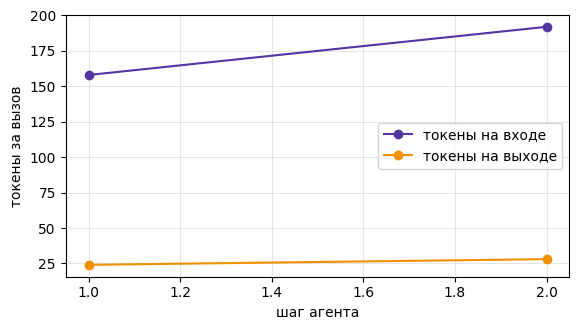

In [ ]:
run = agent("кто выиграл женский US Open 2026 по теннису", MODELS["cheap"], ["web_search"])
show_trace(run)
#context_chart(run);

In [20]:
run = agent("Сколько будет 17 * 23 + 5? Посчитай инструментом.", MODELS["cheap"], ["calculator"])
show_trace(run)

user     | Сколько будет 17 * 23 + 5? Посчитай инструментом. 
assistant|  calculator{"expr":"17*23+5"}
tool     | 396 
assistant| FINAL: 396 
шагов: 2, цена: 0.007 ¢, время: 4.0 c


In [39]:
run = agent("кто выиграл женский US Open 2026 по теннису", MODELS["cheap"], ["web_search"])
show_trace(run)

user     | кто выиграл женский US Open 2026 по теннису 
assistant|  web_search{"query":"2026 US Open women's tennis winner"}
tool     | [2026 US Open (tennis)] <p class="mw-empty-elt"> </p> <p>The <b>2026 US Open</b> was the 146th edition of tennis' US Open, and the fourth and final Grand Slam event of the year. It 
assistant|  web_search{"query":"2026 US Open women's singles champion"}
tool     | [2026 US Open – Women's singles] <p>Elena Rybakina defeated two-time defending champion Aryna Sabalenka in the final, 6–4, 5–7, 6–2 to win the women's singles tennis title at the 2 
assistant| Женский титул на US Open 2026 выиграла Елена Рыбакина, обыграв в финале Арини Сабаленку со счетом 6–4, 5–7, 6–2. FINAL: Елена Рыбакина 
шагов: 3, цена: 0.038 ¢, время: 7.7 c


In [40]:
run = agent("When did football fans first start wearing replica kits?", MODELS["cheap"], ["guardian_search", "guardian_read"])
show_trace(run)

user     | When did football fans first start wearing replica kits? 
assistant|  guardian_search{"query":"history of football fans wearing replica kits"}
tool     | [When did football fans first start wearing replica kits? | The Knowledge] Plus: more costly (and beneficial) red cards and attacks with triple half-century of international goals  
assistant|  guardian_read{"url":"https://www.theguardian.com/football/2026/sep/16/when-did-football-fans-first-start-wearing-replica-kits","keywords":"replica kits"}
tool     | “When did fans wearing replica kits become a thing?” asks Alex Ecob. “Older footage shows people in regular clothes and a few scarves/flags in the team colours. What kickstarted th 
assistant| Football fans first started wearing replica kits in 1973, when Leeds United's manager Don Revie and Admiral's owner Bert Patrick agreed on producing the first official adult replic 
шагов: 3, цена: 0.025 ¢, время: 6.6 c


In [42]:
import json, random

rows = [json.loads(l) for l in open("data/fresh.jsonl", encoding="utf-8")]
random.seed(1)
sample = (random.sample([r for r in rows if r["source"] == "fresh"], 2)
          + random.sample([r for r in rows if r["source"] == "guardian"], 2))

for r in sample:
    tools = ["web_search"] if r["source"] == "fresh" else ["guardian_search", "guardian_read"]
    run = agent(r["question"], MODELS["cheap"], tools)
    show_trace(run)
    print("ожидался ответ:", r["answer"])
    print("=" * 80)

user     | In spaceflight, what was launched by ISRO on September 3, 2026? 
assistant|  web_search{"query":"ISRO launch September 3 2026"}
tool     | [List of spaceflight launches in July–September 2026] <p class="mw-empty-elt"> </p> <p> This article lists orbital and suborbital launches during the third quarter of the year 2026 
assistant|  web_search{"query":"ISRO launch details September 3 2026"}
tool     | [List of spaceflight launches in July–September 2026] <p class="mw-empty-elt"> </p> <p> This article lists orbital and suborbital launches during the third quarter of the year 2026 
assistant|  web_search{"query":"ISRO September 3 2026 launch mission"}
tool     | [List of ISRO missions] <p class="mw-empty-elt"> </p> <p>This is a list of ISRO missions. ISRO has carried out 133 spacecraft missions, 104 launch missions and planned several miss 
assistant| I couldn't find specific information regarding a launch by ISRO on September 3, 2026. It seems that detailed records for that dat

In [ ]:
class BlankArgs(BaseModel):
    text: str

def tool_a(text: str) -> str:
    return calculator(text)

def tool_b(text: str) -> str:
    return python_exec(text)

register(tool_a, BlankArgs, "Инструмент")
register(tool_b, BlankArgs, "Инструмент")
json.dumps(TOOLS["tool_b"]["schema"], ensure_ascii=False)

'{"type": "function", "function": {"name": "tool_b", "description": "Инструмент", "parameters": {"properties": {"text": {"title": "Text", "type": "string"}}, "required": ["text"], "title": "BlankArgs", "type": "object"}}}'

## Спринт 6. Прогон, трейсы, деньги

`run_tasks` прогоняет список задач в одной конфигурации, считает цену, время и число вызовов инструментов на задачу, проверяет ответ и пишет трейс в `traces/<конфигурация>/<модель>/<id>.json`. `report` сводит результаты в таблицу с главной колонкой курса `cost_per_correct`. `money_chart` рисует цену задачи против доли верных: левый верхний угол это «дёшево и хорошо», туда мы и хотим попасть. `steps_chart` показывает шаги, вызовы инструментов и секунды по конфигурациям.

На семинаре: пять задач GSM8K в четырёх конфигурациях (без инструментов, калькулятор, код, безымянные инструменты), три задачи HotpotQA в двух (без инструментов, поиск), всё на дешёвой модели, плюс сильная модель без инструментов на тех же восьми задачах.

Затем три повтора одного и того же прогона. Доля верных гуляет от повтора к повтору, и это первый разговор о размере выборки: домашка делается на 80 задачах именно поэтому. Ячейка с трейсом печатает один прогон по шагам: читать трейсы вслух это главный навык отладки агентов.

In [ ]:
def final_answer(text):
    m = re.search(r"FINAL:\s*(.+)", text or "")
    return m.group(1).strip() if m else (text or "").strip()

def run_tasks(tasks, model, tool_names, config):
    folder = TRACES / config / model.split("/")[-1]
    folder.mkdir(parents=True, exist_ok=True)
    rows = []
    for task in tasks:
        try:
            run = agent(task["question"], model, tool_names)
        except Exception as e:
            run = Run(task["question"], f"ошибка: {e}", 0, [])
        ok = is_correct(task, final_answer(run.answer))
        rows.append({"config": config, "model": model.split("/")[-1], "id": task["id"], "source": task["source"],
                     "correct": ok, "steps": run.steps, "tool_calls": sum(m["role"] == "tool" for m in run.messages),
                     "cost": run.cost, "seconds": round(run.seconds, 1), "answer": final_answer(run.answer)[:60], "gold": task["answer"]})
        (folder / f"{task['id']}.json").write_text(json.dumps({"task": task, "answer": run.answer, "correct": ok, "cost": run.cost,
                                                              "messages": run.messages}, ensure_ascii=False, indent=1), encoding="utf-8")
    return pd.DataFrame(rows)

def report(results):
    rows = [summary(config, model, len(df), int(df["correct"].sum()), df["cost"].sum(), df["steps"].mean(), df["seconds"].mean())
            for (config, model), df in results.groupby(["config", "model"])]
    return pd.DataFrame(rows).sort_values("cost_per_task").reset_index(drop=True)

def money_chart(table, path="img/money_quality.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in table.iterrows():
        color = COLORS["red"] if "каскад" in r["config"] else COLORS["amber"] if "sonnet" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена задачи, центы (логарифмическая шкала)")
    ax.set_ylabel("доля верных ответов, %")
    ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

def steps_chart(results):
    g = results.groupby("config").agg(steps=("steps", "mean"), tool_calls=("tool_calls", "mean"), seconds=("seconds", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    g[["steps", "tool_calls"]].plot.bar(ax=axes[0], color=[COLORS["violet"], COLORS["teal"]], rot=12)
    axes[0].set_ylabel("в среднем на задачу")
    g["seconds"].plot.bar(ax=axes[1], color=COLORS["amber"], rot=12)
    axes[1].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.grid(alpha=0.3, axis="y")
        ax.set_xlabel("")
    fig.tight_layout()
    return fig

CONFIGS = {"без инструментов": [], "калькулятор": ["calculator"], "код": ["python_exec"], "поиск": ["web_search"],
           "безымянные": ["tool_a", "tool_b"]}

In [ ]:
gsm = load_tasks("/kaggle/input/datasets/artmakar04/qa-data/gsm8k_50.jsonl")[:5]
hotpot = load_tasks("/kaggle/input/datasets/artmakar04/qa-data/hotpot_30.jsonl")[:3]
frames = [run_tasks(gsm, MODELS["cheap"], CONFIGS[c], c) for c in ["без инструментов", "калькулятор", "код", "безымянные"]]
frames += [run_tasks(hotpot, MODELS["cheap"], CONFIGS[c], c) for c in ["без инструментов", "поиск"]]
frames.append(run_tasks(gsm + hotpot, MODELS["strong"], [], "без инструментов"))
results = pd.concat(frames, ignore_index=True)
results[["config", "model", "id", "correct", "steps", "tool_calls", "cost", "seconds", "answer", "gold"]]

,config,model,id,correct,steps,tool_calls,cost,seconds,answer,gold
0,без инструментов,gpt-4o-mini,gsm8k-0,True,1,0,0.000084,1.4,18,18
1,без инструментов,gpt-4o-mini,gsm8k-1,True,1,0,0.000072,1.2,3,3
2,без инструментов,gpt-4o-mini,gsm8k-2,True,1,0,0.000127,3.0,70000,70000
3,без инструментов,gpt-4o-mini,gsm8k-3,True,1,0,0.000081,2.2,540,540
4,без инструментов,gpt-4o-mini,gsm8k-4,True,1,0,0.000133,2.9,20,20
5,калькулятор,gpt-4o-mini,gsm8k-0,True,2,1,0.000085,1.3,18,18
6,калькулятор,gpt-4o-mini,gsm8k-1,True,2,1,0.000068,1.2,3,3
7,калькулятор,gpt-4o-mini,gsm8k-2,False,3,3,0.000173,2.5,65000,70000
8,калькулятор,gpt-4o-mini,gsm8k-3,True,3,2,0.000129,2.1,540,540
9,калькулятор,gpt-4o-mini,gsm8k-4,True,2,1,0.000097,1.3,20,20


In [ ]:
table = report(results)
table

,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,без инструментов,gpt-4o-mini,8,0.75,0.00008,0.00010,1.0,1.7
1,калькулятор,gpt-4o-mini,5,0.80,0.00011,0.00014,2.4,1.7
2,код,gpt-4o-mini,5,0.80,0.00067,0.00083,4.8,10.9
3,поиск,gpt-4o-mini,3,0.67,0.00070,0.00104,4.0,5.8
4,безымянные,gpt-4o-mini,5,1.00,0.00114,0.00114,7.0,14.1
5,без инструментов,claude-sonnet-4.6,8,1.00,0.00200,0.00200,1.0,2.9


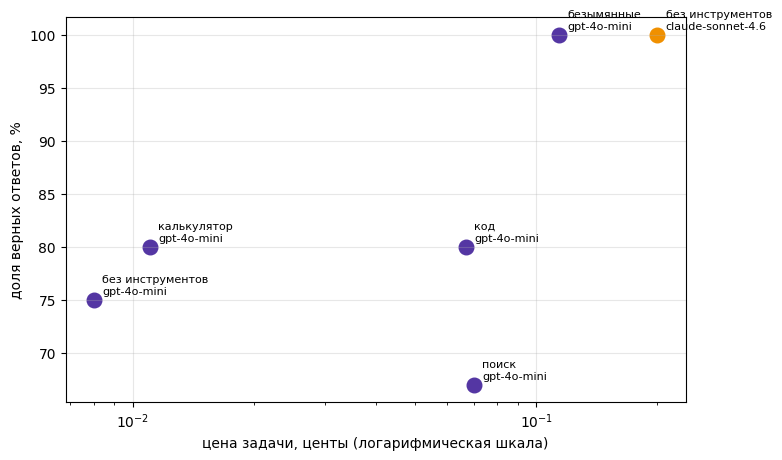

In [ ]:
money_chart(table);

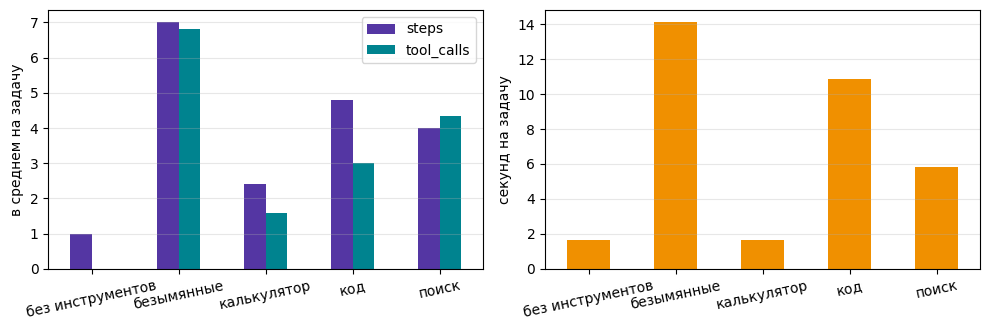

In [ ]:
steps_chart(results[results["model"] == "gpt-4o-mini"]);

In [ ]:
trace = json.loads(next((TRACES / "код" / "gpt-4o-mini").glob("gsm8k-*.json")).read_text(encoding="utf-8"))
show_trace(Run(trace["task"]["question"], trace["answer"], sum(m["role"] == "assistant" for m in trace["messages"]), trace["messages"], trace["cost"]))

user     | James decides to run 3 sprints 3 times a week. He runs 60 meters each sprint. How many total meters does he run a week? 
assistant|  python_exec{"code":"sprints_per_week = 3 * 3  # 3 sprints, 3 times a week\nmeters_per_sprint = 60\n# Total meters run in a week\ntotal_meters_per_week = sprints_per_week * meters_per_sprint\nprint(total_meters_per_week)"}
tool     | 540 
assistant| FINAL: 540 
шагов: 2, цена: 0.011 ¢, время: 0.0 c


In [ ]:
repeats = pd.concat([run_tasks(gsm, MODELS["cheap"], ["python_exec"], f"код, повтор {i + 1}") for i in range(3)], ignore_index=True)
repeat_table = report(repeats)
repeat_table[["config", "accuracy", "cost_per_task", "avg_steps"]]

,config,accuracy,cost_per_task,avg_steps
0,"код, повтор 3",0.8,0.00027,3.0
1,"код, повтор 2",0.8,0.00046,4.0
2,"код, повтор 1",0.8,0.00094,6.4


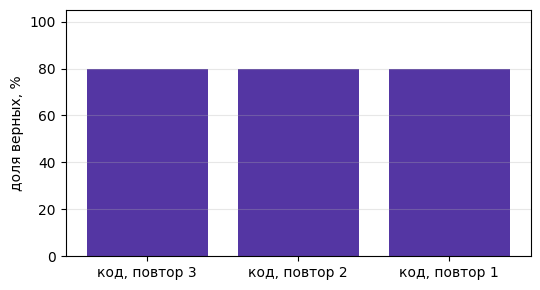

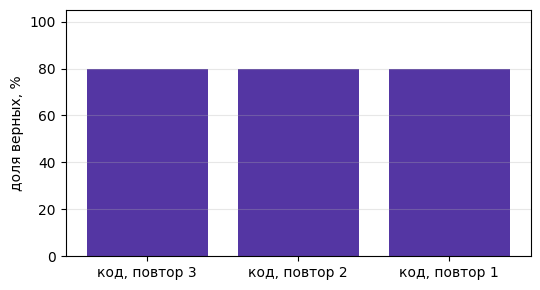

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(repeat_table["config"], repeat_table["accuracy"] * 100, color=COLORS["violet"])
ax.set_ylim(0, 105)
ax.set_ylabel("доля верных, %")
ax.grid(alpha=0.3, axis="y")
fig

In [ ]:
ledger.table(), round(ledger.total, 3)

(                               calls  prompt  completion     cost  seconds
 tag         model                                                         
 agent       claude-haiku-4.5       4    7727         395  0.00970     6.46
             claude-sonnet-4.6     30   23829        3444  0.12315    88.12
             gpt-4o-mini          219  123467       15246  0.02585   317.90
 hello       gpt-4o-mini            1      18           5  0.00001     0.75
 struct      claude-haiku-4.5      14    4457        1673  0.01282    23.98
             claude-sonnet-4.6     10    2273         967  0.02132    23.17
             gpt-4o-mini           16    2883        1056  0.00107    26.28
 temperature gpt-4o-mini           10     270          76  0.00009     9.28
 window      claude-haiku-4.5       2      83         414  0.00215     5.19
             claude-sonnet-4.6      2      83         492  0.00763    11.89
             gpt-4o-mini            2      62         207  0.00013     4.11,
 0.204)

## Спринт 7. Каскад: дешёвая модель первой, сильная по необходимости

Идея FrugalGPT в самом простом виде. Дешёвая модель отвечает и заявляет уверенность от 0 до 1 (схема `Confident`). Если уверенность ниже порога, задача уходит сильной модели. `confident_answer` запоминает ответы каждой модели по задаче, поэтому развёртка по порогам не делает лишних вызовов: каждая модель спрашивается один раз на задачу, дальше арифметика.

Дырка одна: сам каскад. `cascade_sweep` считает точность, цену задачи и долю задач, ушедших наверх, для нескольких порогов: порог 0 это только дешёвая модель, порог 1.01 это сильная плюс потраченный впустую вызов дешёвой. `cascade_chart` рисует кривую цена против точности. `confidence_chart` показывает, чему верить: гистограмма заявленной уверенности отдельно для верных и неверных ответов. Последняя картинка спринта собирает все конфигурации семинара и точки каскада на одном поле.

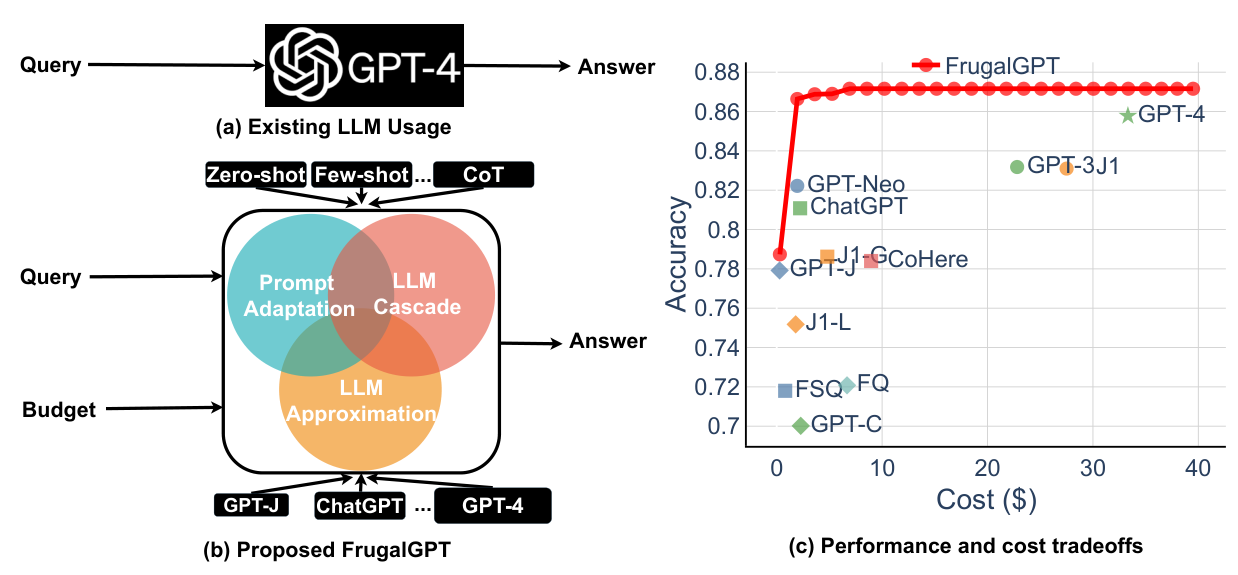

*Chen, Zaharia, Zou, 2023. FrugalGPT: каскад из дешёвых и сильных моделей достигает точности GPT-4 при цене в разы ниже. Красная линия это тезис курса одной картинкой*

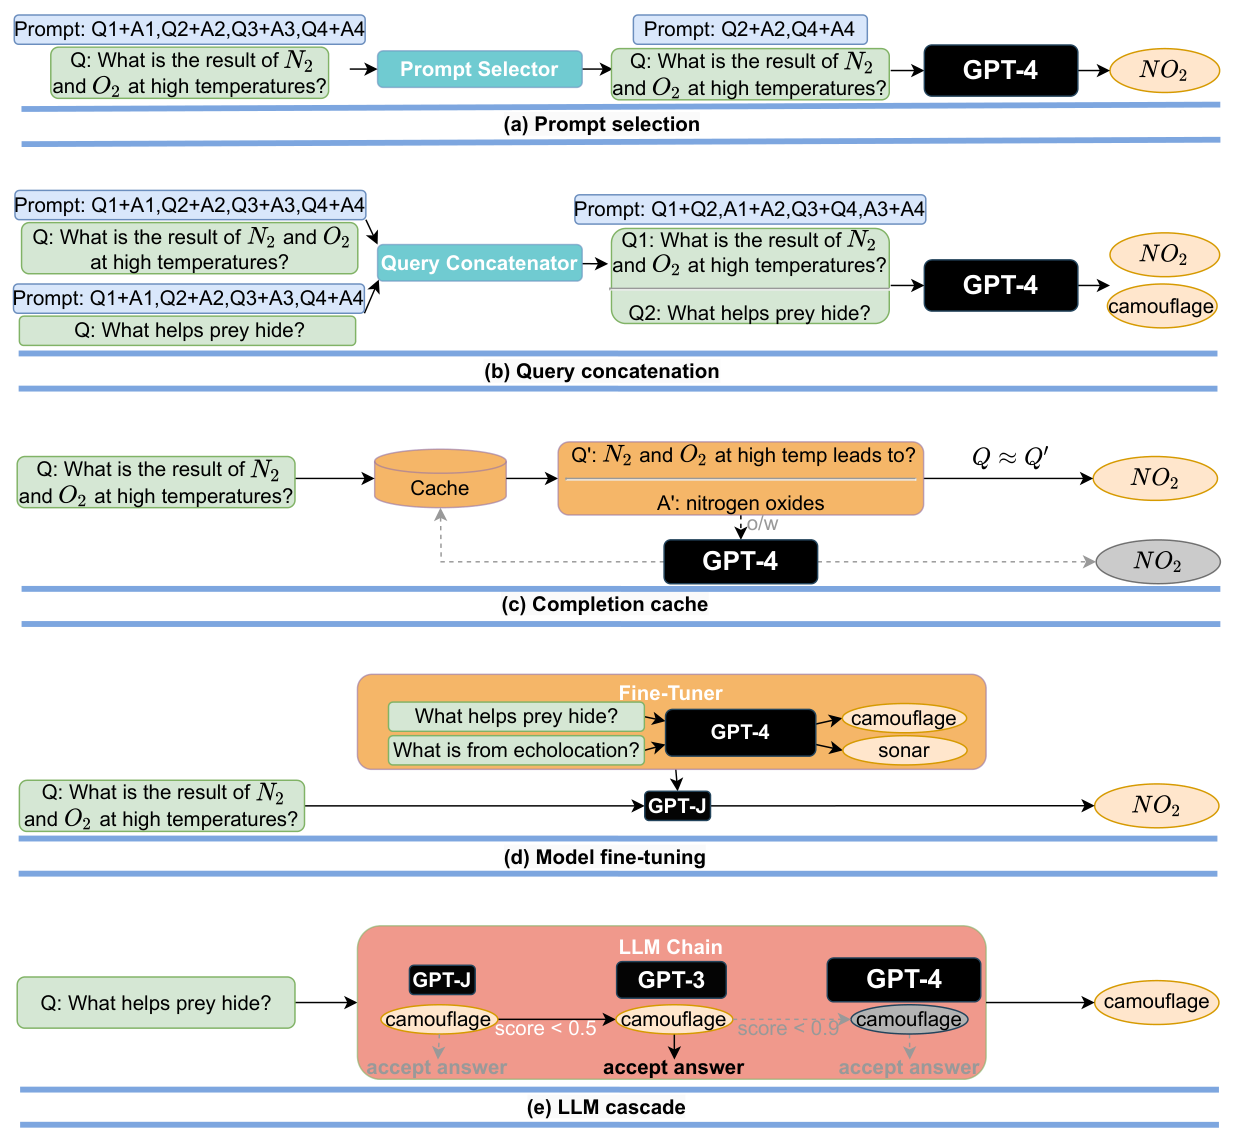

*Там же: пять приёмов в трёх семействах. Адаптация промпта (a, b), приближение сильной модели дешёвой через кэш и дообучение (c, d) и каскад (e). На семинаре собираем каскад*

In [ ]:
class Confident(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ")
    confidence: float = Field(description="честная уверенность в ответе от 0 до 1")

MEMO = {}

def confident_answer(task, model):
    key = (task["id"], model)
    if key not in MEMO:
        before = ledger.total
        try:
            ans = ask_structured(task["question"], model, Confident)
            MEMO[key] = {"final": ans.final, "confidence": ans.confidence, "correct": is_correct(task, ans.final)}
        except Exception:
            MEMO[key] = {"final": "", "confidence": 0.0, "correct": False}
        MEMO[key]["cost"] = ledger.total - before
    return dict(MEMO[key])

In [ ]:
def cascade(task, threshold):
    cheap = confident_answer(task, MODELS['cheap'])
    if cheap["confidence"] >= threshold:
        return {**cheap, "escalated": False}
    strong = confident_answer(task, MODELS['strong'])
    return {**strong, "cost": cheap["cost"] + strong["cost"], "escalated": True}


In [ ]:
def cascade_sweep(tasks, thresholds):
    rows = []
    for th in thresholds:
        outs = [cascade(t, th) for t in tasks]
        rows.append({"threshold": th, "accuracy": sum(o["correct"] for o in outs) / len(outs),
                     "cost_per_task": sum(o["cost"] for o in outs) / len(outs),
                     "escalated": sum(o["escalated"] for o in outs) / len(outs)})
    df = pd.DataFrame(rows)
    df["cost_per_correct"] = df["cost_per_task"] / df["accuracy"].replace(0, float("nan"))
    return df.round(5)

def cascade_chart(df):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(df["cost_per_task"] * 100, df["accuracy"] * 100, marker="o", color=COLORS["red"])
    for _, r in df.iterrows():
        ax.annotate(f"порог {r['threshold']}, наверх {r['escalated']:.0%}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    xytext=(6, -12), textcoords="offset points", fontsize=8)
    ax.set_xlabel("цена задачи, центы")
    ax.set_ylabel("доля верных, %")
    ax.grid(alpha=0.3)
    return fig

def confidence_chart(tasks, model):
    df = pd.DataFrame([confident_answer(t, model) for t in tasks])
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.hist(df[df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["teal"], label="верные")
    ax.hist(df[~df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["red"], label="неверные")
    ax.set_xlabel("заявленная уверенность")
    ax.set_ylabel("задач")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

In [ ]:
cascade_tasks = load_tasks("/kaggle/input/datasets/artmakar04/qa-data/gsm8k_50.jsonl")[5:25]
cascade_df = cascade_sweep(cascade_tasks, [0.0, 0.7, 0.85, 0.95, 1.01])
cascade_df

,threshold,accuracy,cost_per_task,escalated,cost_per_correct
0,0.00,0.90,0.00009,0.0,0.00011
1,0.70,0.90,0.00009,0.0,0.00011
2,0.85,0.90,0.00009,0.0,0.00011
3,0.95,0.95,0.00174,0.5,0.00183
4,1.01,0.90,0.00286,1.0,0.00318


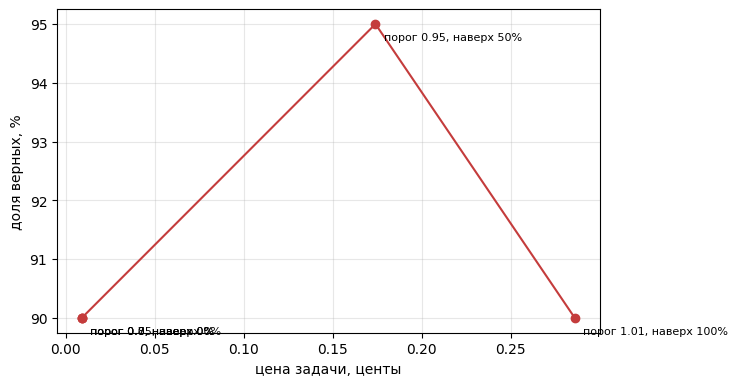

In [ ]:
cascade_chart(cascade_df);

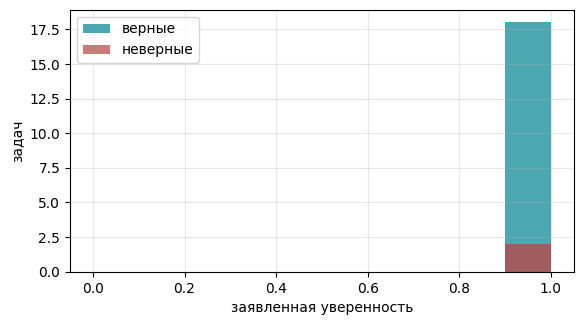

In [ ]:
confidence_chart(cascade_tasks, MODELS["cheap"]);

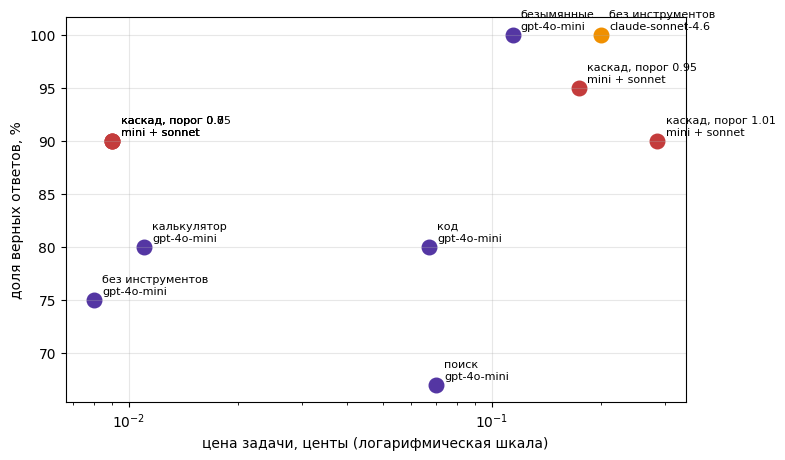

In [ ]:
extra = pd.DataFrame([{"config": f"каскад, порог {r.threshold}", "model": "mini + sonnet", "n": len(cascade_tasks),
                       "accuracy": r.accuracy, "cost_per_task": r.cost_per_task, "cost_per_correct": r.cost_per_correct,
                       "avg_steps": 1, "avg_seconds": 0} for r in cascade_df.itertuples()])
money_chart(pd.concat([table, extra], ignore_index=True), "img/money_quality_all.png");

In [ ]:
ledger.table(), round(ledger.total, 3)

(                               calls  prompt  completion     cost  seconds
 tag         model                                                         
 agent       claude-haiku-4.5       4    7727         395  0.00970     6.46
             claude-sonnet-4.6     30   23829        3444  0.12315    88.12
             gpt-4o-mini          219  123467       15246  0.02585   317.90
 hello       gpt-4o-mini            1      18           5  0.00001     0.75
 struct      claude-haiku-4.5      14    4457        1673  0.01282    23.98
             claude-sonnet-4.6     32    8429        3420  0.07659    81.69
             gpt-4o-mini           36    7340        3100  0.00296    69.78
 temperature gpt-4o-mini           10     270          76  0.00009     9.28
 window      claude-haiku-4.5       2      83         414  0.00215     5.19
             claude-sonnet-4.6      2      83         492  0.00763    11.89
             gpt-4o-mini            2      62         207  0.00013     4.11,
 0.261)

## Домашка

Срок: воскресенье 20.09, 23:59, ссылкой на репозиторий. Поставьте `HOMEWORK = True` и запустите: 50 задач GSM8K и 30 HotpotQA, дешёвая и средняя модели во всех конфигурациях, сильная без инструментов. Около часа и около доллара. Результаты лягут в `results.md`, `results_raw.csv` и `img/homework.png`. Что должно быть в репозитории и как оценивается, в `README.md`.

In [ ]:
HOMEWORK = True
if HOMEWORK:
    gsm, hotpot = load_tasks("gsm8k_50.jsonl"), load_tasks("hotpot_30.jsonl")
    frames = []
    for name in ["cheap", "mid"]:
        frames += [run_tasks(gsm, MODELS[name], CONFIGS[c], c) for c in ["без инструментов", "калькулятор", "код"]]
        frames += [run_tasks(hotpot, MODELS[name], CONFIGS[c], c) for c in ["без инструментов", "поиск"]]
    frames.append(run_tasks(gsm + hotpot, MODELS["strong"], [], "без инструментов"))
    homework = pd.concat(frames, ignore_index=True)
    homework.to_csv("results_raw.csv", index=False)
    homework_table = report(homework)
    Path("results.md").write_text(homework_table.to_string(index=False), encoding="utf-8")
    money_chart(homework_table, "img/homework.png")
    homework_table